<a href="https://colab.research.google.com/github/izeeqpotter/Breast_Cancer/blob/main/HeartDiseasePred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A Heart Disease Prediction Using Logistics Regression and Random Forest

# Task
Perform a comprehensive analysis of the 'heart.csv' dataset to predict heart disease. This analysis should include data preprocessing, exploratory data analysis with visualizations, feature selection using PCA, and training and evaluating both Logistic Regression and Random Forest models. The evaluation should include accuracy, recall, F1-score, precision, confusion matrix, and AUC-ROC curve for both training and test sets, with visualizations for the metrics.

## Import Libraries

### Subtask:
Import all necessary Python libraries for data manipulation, visualization, machine learning model building (Logistic Regression, Random Forest), data preprocessing (SMOTE, StandardScaler), feature selection (PCA), and model evaluation.


**Reasoning**:
The subtask requires importing all specified Python libraries for data manipulation, visualization, model building, preprocessing, feature selection, and evaluation.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                             precision_score, confusion_matrix, roc_curve,
                             auc, RocCurveDisplay)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset

### Subtask:
Load the heart disease dataset, which is available as 'heart.csv' in the kernel, into a pandas DataFrame.


**Reasoning**:
Load the 'heart.csv' file into a pandas DataFrame, display its first few rows, and print its shape to verify the data loading.



In [2]:
df = pd.read_csv('heart.csv')
print("First 5 rows of the dataset:")
print(df.head())
print("\nShape of the dataset:")
print(df.shape)

First 5 rows of the dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Shape of the dataset:
(1025, 14)


## Data Preprocessing and Balancing

### Subtask:
Perform data preprocessing steps including checking for missing values, handling duplicate entries, ensuring correct data types, and addressing class imbalance using the SMOTE technique. Handle any other issues identified during this phase.


**Reasoning**:
The first step in data preprocessing is to check for any missing values in the dataset. This helps in understanding the completeness of the data and planning subsequent imputation or cleaning steps. The instruction specifically asks to use `.isnull().sum()`.



In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


**Reasoning**:
After checking for missing values, the next logical step in data preprocessing is to identify and handle duplicate entries. This helps in ensuring data integrity and avoiding bias in subsequent analyses. The instruction specifically asks to use `.duplicated().sum()` to count duplicates, and then `.drop_duplicates()` if any are found.



In [4]:
print("Number of duplicate rows before removal:", df.duplicated().sum())

df.drop_duplicates(inplace=True, ignore_index=True)

print("Number of duplicate rows after removal:", df.duplicated().sum())
print("Shape of the DataFrame after removing duplicates:", df.shape)

Number of duplicate rows before removal: 723
Number of duplicate rows after removal: 0
Shape of the DataFrame after removing duplicates: (302, 14)


**Reasoning**:
The next step in data preprocessing is to verify the data types of all columns using `df.info()` to ensure they are appropriate for analysis and to identify any columns that might need type conversion.



In [5]:
print("Data types of each column:")
df.info()

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB


**Reasoning**:
After verifying data types, the next step is to separate the features (X) from the target variable (y), which is 'target', to prepare for model training and balancing.



In [6]:
X = df.drop('target', axis=1)
y = df['target']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (302, 13)
Target (y) shape: (302,)


**Reasoning**:
The next step is to check for class imbalance in the target variable `y` by printing its value counts, as this is a crucial step before applying techniques like SMOTE.



In [7]:
print("Class distribution of target variable (y):")
print(y.value_counts())

Class distribution of target variable (y):
target
1    164
0    138
Name: count, dtype: int64


**Reasoning**:
Since the task explicitly mentions addressing class imbalance using SMOTE, the next logical step is to apply the SMOTE technique to the features (X) and target (y) to balance the classes and then confirm the new class distribution.



In [8]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Class distribution of target variable (y) after SMOTE:")
print(y_resampled.value_counts())

Class distribution of target variable (y) after SMOTE:
target
0    164
1    164
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

### Subtask:
Conduct a thorough exploratory data analysis. This involves generating clear and clean visualizations (e.g., histograms, box plots, scatter plots, correlation matrices) with appropriate charts and graphs, and providing interpretations of the findings to understand the dataset's characteristics and relationships between features. Ensure all visualizations include legends.


**Reasoning**:
The first step in the EDA subtask is to combine the resampled features (`X_resampled`) and the resampled target variable (`y_resampled`) into a single DataFrame, `df_eda`, to facilitate a comprehensive analysis of the balanced dataset.



In [9]:
df_eda = pd.concat([X_resampled, y_resampled], axis=1)

print("First 5 rows of the combined DataFrame (df_eda):")
print(df_eda.head())
print("\nShape of the combined DataFrame (df_eda):")
print(df_eda.shape)

First 5 rows of the combined DataFrame (df_eda):
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Shape of the combined DataFrame (df_eda):
(328, 14)


**Reasoning**:
The next step in the EDA process is to display descriptive statistics of `df_eda` using the `.describe()` method. This will provide a quick overview of the central tendency, dispersion, and shape of each feature's distribution, helping to identify potential outliers or issues.



In [10]:
print("Descriptive statistics of the combined DataFrame (df_eda):")
print(df_eda.describe())

Descriptive statistics of the combined DataFrame (df_eda):
              age         sex          cp    trestbps        chol         fbs  \
count  328.000000  328.000000  328.000000  328.000000  328.000000  328.000000   
mean    54.509146    0.673780    0.905488  132.439024  247.152439    0.143293   
std      8.880445    0.469545    1.016786   18.017557   52.323750    0.350906   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    1.000000  130.000000  242.500000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  277.250000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  328.000000  328.000000  328.000000  328.000000  328.000000  328.000000   
mean     0.496951  148.335366    0.329268    1.09

**Reasoning**:
The next step in EDA is to generate histograms for each feature in `df_eda` to visualize their distributions. This helps in understanding the spread and shape of the data for each variable.



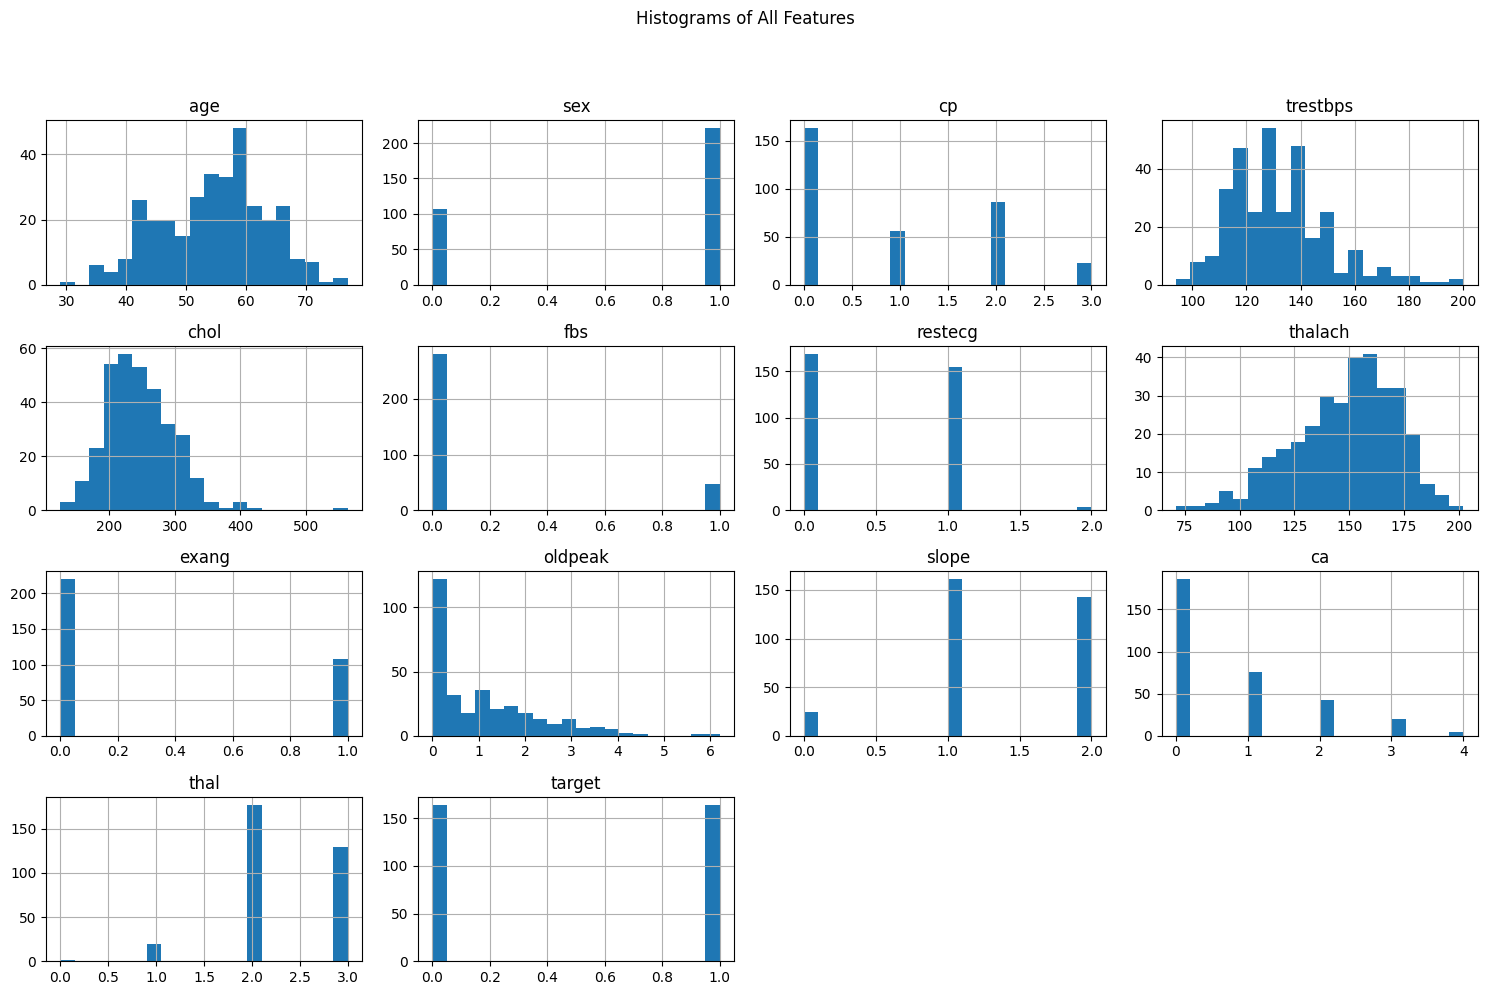

Histograms for all features displayed.


In [11]:
df_eda.hist(figsize=(15, 10), layout=(4, 4), bins=20)
plt.suptitle('Histograms of All Features', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()
print("Histograms for all features displayed.")

**Reasoning**:
The next step in the EDA process is to create a correlation matrix of `df_eda` and visualize it using a heatmap. This helps in understanding the linear relationships between all features, especially their correlation with the 'target' variable.



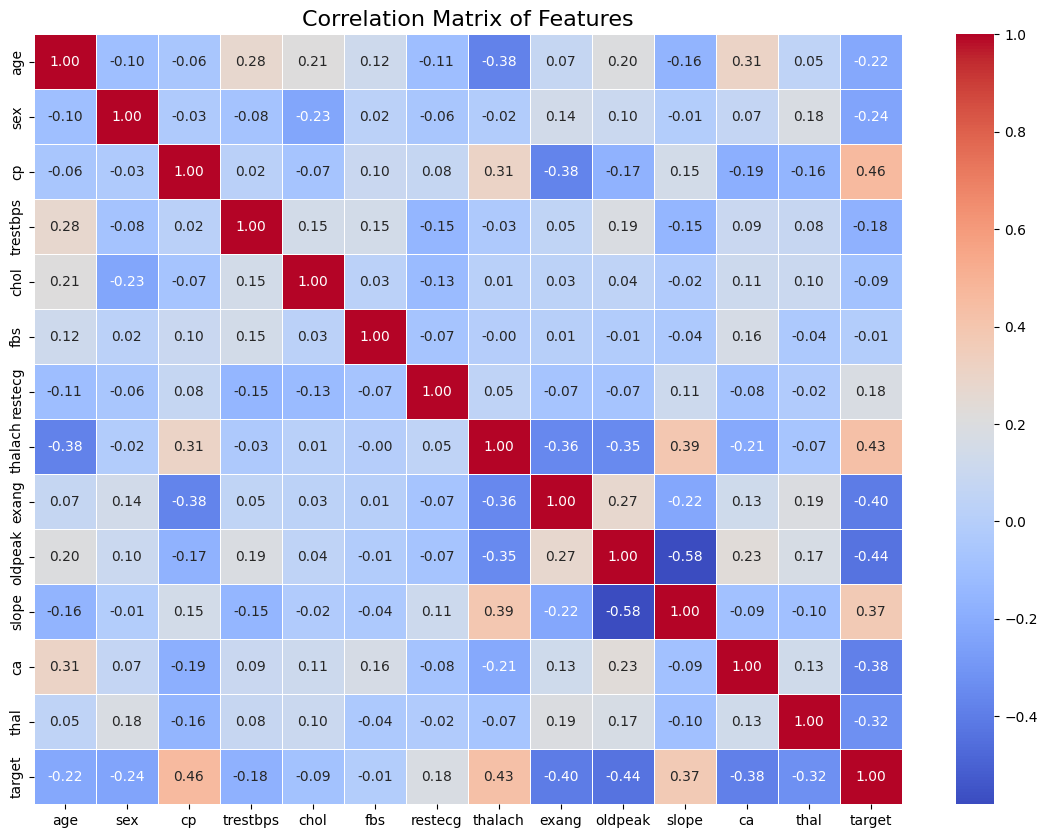

Interpretation of Correlation Matrix:
The heatmap visualizes the Pearson correlation coefficients between all pairs of features in the dataset.
- Positive values indicate a positive correlation (as one variable increases, the other tends to increase).
- Negative values indicate a negative correlation (as one variable increases, the other tends to decrease).
- Values close to 1 or -1 indicate a strong linear relationship, while values close to 0 indicate a weak or no linear relationship.
Special attention should be paid to the 'target' row/column to identify features most strongly correlated with heart disease presence.


In [12]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_eda.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()

print("Interpretation of Correlation Matrix:")
print("The heatmap visualizes the Pearson correlation coefficients between all pairs of features in the dataset.")
print("- Positive values indicate a positive correlation (as one variable increases, the other tends to increase).")
print("- Negative values indicate a negative correlation (as one variable increases, the other tends to decrease).")
print("- Values close to 1 or -1 indicate a strong linear relationship, while values close to 0 indicate a weak or no linear relationship.")
print("Special attention should be paid to the 'target' row/column to identify features most strongly correlated with heart disease presence.")


**Reasoning**:
The final step in EDA, as per the instructions, is to visualize the distribution of selected categorical-like features ('sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal') and their relationship with the 'target' variable using count plots or bar plots.



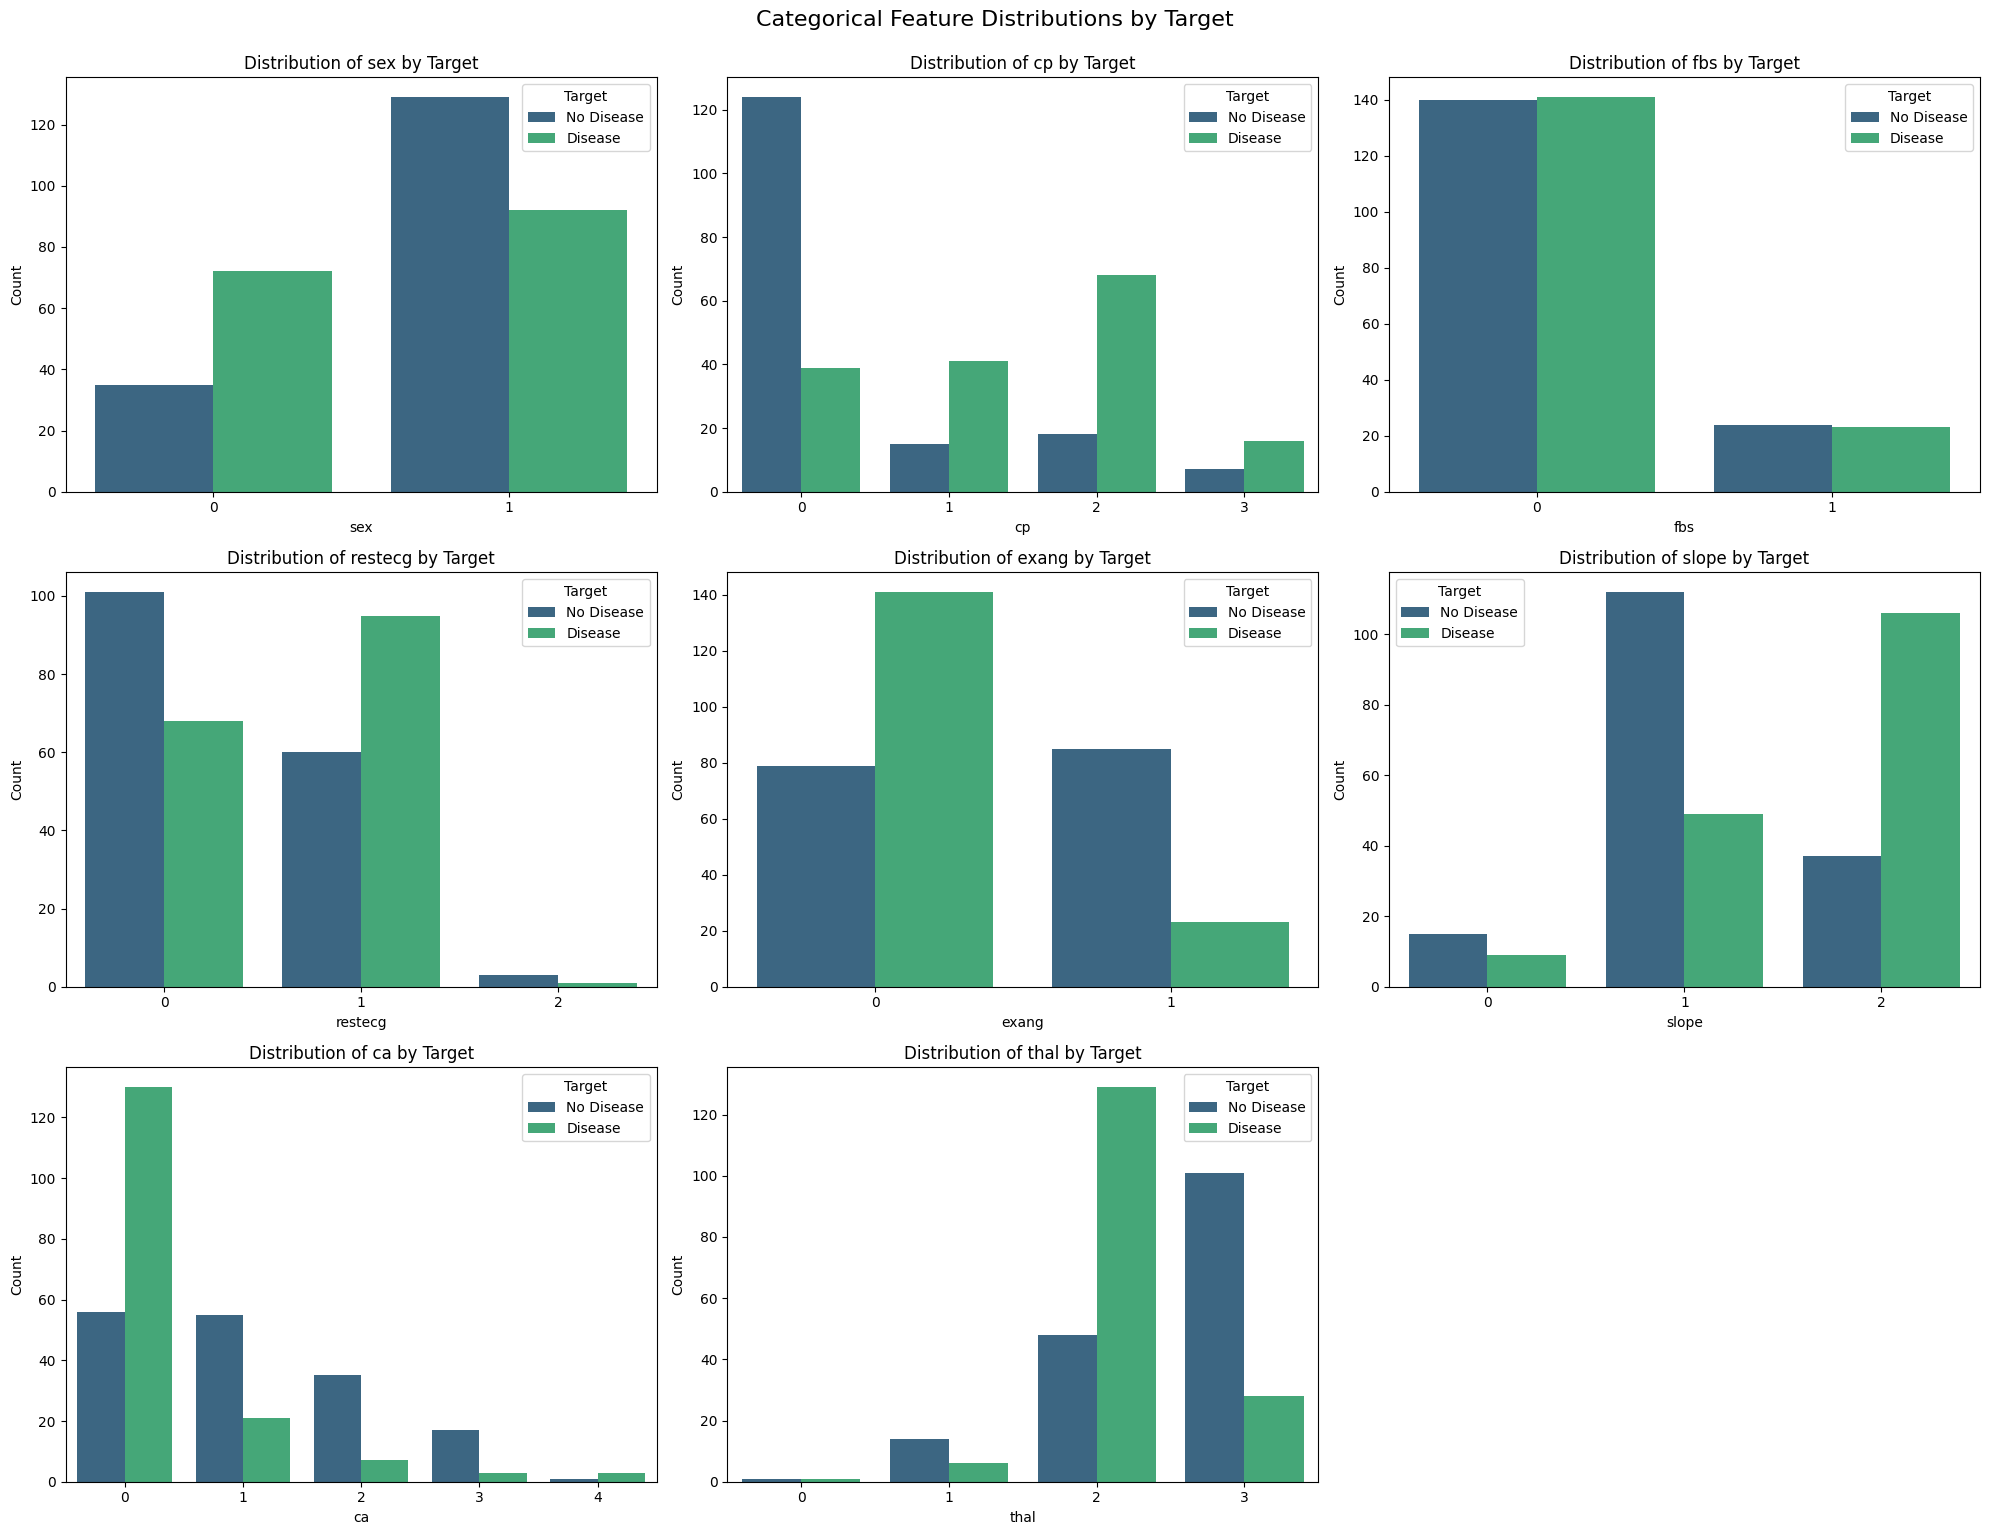

Count plots for selected categorical features displayed.


In [13]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(20, 15))
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    sns.countplot(x=feature, hue='target', data=df_eda, palette='viridis')
    plt.title(f'Distribution of {feature} by Target', fontsize=12)
    plt.xlabel(feature, fontsize=10)
    plt.ylabel('Count', fontsize=10)
    plt.legend(title='Target', labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.suptitle('Categorical Feature Distributions by Target', y=1.02, fontsize=16)
plt.show()

print("Count plots for selected categorical features displayed.")

## Feature Selection and Dimensionality Reduction

### Subtask:
Select important features for model training and reduce the dimensionality of the dataset using Principal Component Analysis (PCA).


**Reasoning**:
The first step in applying PCA is to standardize the data, as PCA is sensitive to the scale of features. This will scale the `X_resampled` data using `StandardScaler` and store it in `X_scaled`.



In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

print("Shape of X_resampled before scaling:", X_resampled.shape)
print("Shape of X_scaled after scaling:", X_scaled.shape)
print("First 5 rows of X_scaled (standardized data):\n", X_scaled[:5])

Shape of X_resampled before scaling: (328, 13)
Shape of X_scaled after scaling: (328, 13)
First 5 rows of X_scaled (standardized data):
 [[-0.28297907  0.69581815 -0.89189994 -0.41350725 -0.67285215 -0.40897407
   0.96035792  0.84324867 -0.70064905 -0.08213804  1.03705803  1.30006663
   1.10849285]
 [-0.17020005  0.69581815 -0.89189994  0.42028606 -0.84512097  2.44514282
  -0.94871722  0.2857894   1.42724806  1.71750187 -2.21801406 -0.73051363
   1.10849285]
 [ 1.74704332  0.69581815 -0.89189994  0.69821716 -1.40020941 -0.40897407
   0.96035792 -1.00065509  1.42724806  1.28901618 -2.21801406 -0.73051363
   1.10849285]
 [ 0.73203212  0.69581815 -0.89189994  0.86497582 -0.84512097 -0.40897407
   0.96035792  0.54307829 -0.70064905 -0.93910942  1.03705803  0.2847765
   1.10849285]
 [ 0.84481115 -1.43715711 -0.89189994  0.30911361  0.89670825  2.44514282
   0.96035792 -1.81540327 -0.70064905  0.68913621 -0.59047802  2.31535675
  -0.52193609]]


**Reasoning**:
Following the data standardization, the next step is to initialize the PCA model, fit it to the scaled data, and then transform the scaled data into principal components as per steps 2, 3, and 4 of the instructions.



In [15]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Shape of X_pca (transformed data):")
print(X_pca.shape)
print("First 5 rows of X_pca (principal components):\n", X_pca[:5])

Shape of X_pca (transformed data):
(328, 13)
First 5 rows of X_pca (principal components):
 [[-0.5507627  -0.99375423  0.56287062  1.38083908  0.7357479   1.39247911
  -0.59115198 -0.12329327  1.17915394  0.4978519  -0.38737347  0.32635657
   0.14796887]
 [ 2.48292193 -0.81470249  1.99436206 -0.87923692 -1.08098689 -0.845022
   2.08715885 -0.73694942 -0.24238383  0.88993617 -0.39237898  1.17964522
  -0.26726655]
 [ 2.96666705 -1.47099766 -0.01412559 -1.42678947 -0.32206897  1.03579557
   0.40097743  1.46233835 -0.5534667   0.37640146 -0.47543699  1.06201162
  -0.98627975]
 [-0.53703919 -0.24210689  0.51346177  1.17784268  0.49544011  1.29590005
  -0.31517569  1.59444208  0.62144     0.63003426 -0.95118867  0.28216234
  -0.29783143]
 [ 2.20520733  2.07742172 -0.31284282 -0.41261735  2.55091427  0.61071878
   0.94811719 -1.42152653  0.65041348  0.68787318 -0.62521763 -0.86892888
   0.57448604]]


**Reasoning**:
The next step is to calculate and plot the explained variance ratio for each principal component. This visualization will help determine the optimal number of components to retain, as stated in instruction 6 of the subtask.



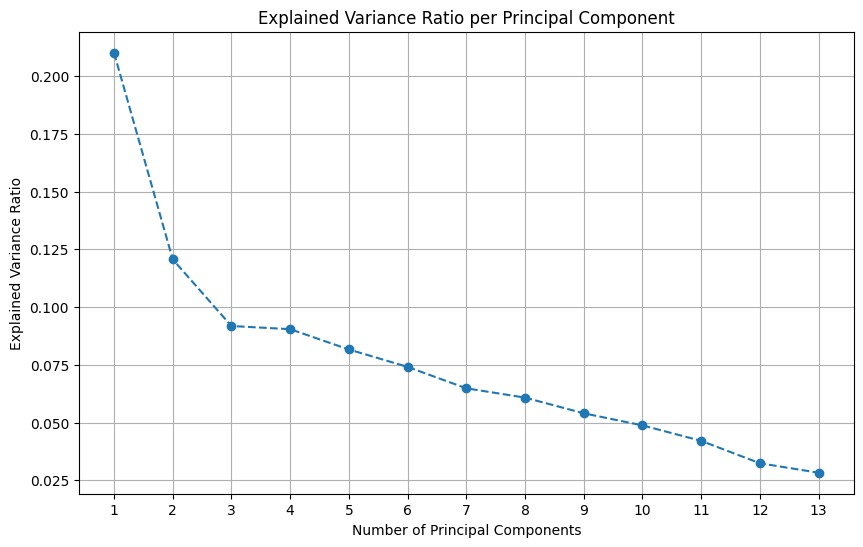

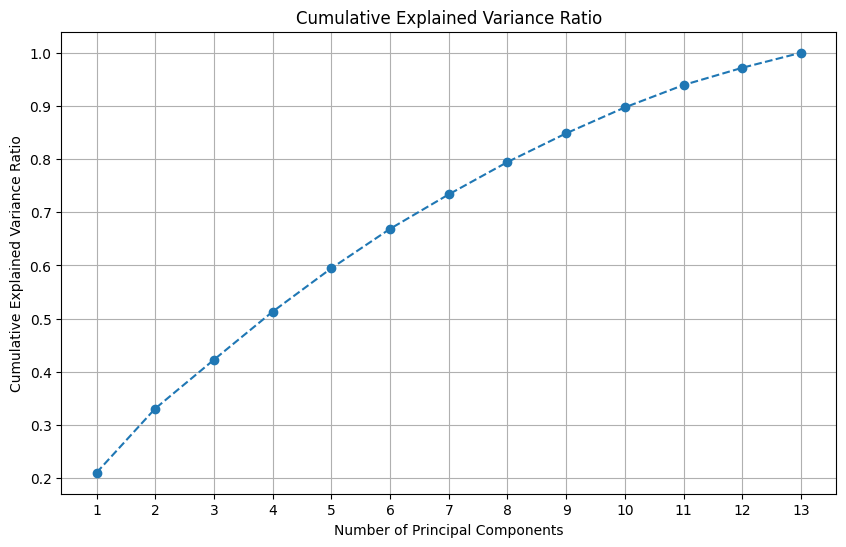

Explained variance ratio for each component and cumulative explained variance plot displayed.


In [16]:
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(explained_variance) + 1))
plt.show()

cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance Ratio')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.show()

print("Explained variance ratio for each component and cumulative explained variance plot displayed.")

### Interpretation of PCA Results:
From the cumulative explained variance plot, we can observe how many principal components are needed to explain a certain percentage of the total variance in the dataset. A common threshold is to retain components that collectively explain around 90-95% of the variance.

Looking at the plot, we can identify the 'elbow' point or the number of components where the cumulative explained variance curve starts to flatten. This point suggests that adding more components beyond this point does not significantly increase the explained variance, but only adds noise.

Based on the plot, we will select an optimal number of components to proceed with the next steps of model training. For instance, if 7 components explain roughly 90% of the variance, we would choose 7. We can visually inspect the `cumulative_variance` array or the plot to make this decision.

**Reasoning**:
Now that we have visualized the explained variance, the next step is to explicitly select the optimal number of principal components. We will choose the number of components that explain at least 95% of the cumulative variance, as this is a common practice to reduce dimensionality while retaining most of the information.



In [17]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of components explaining at least 95% of variance: {n_components}")

pca = PCA(n_components=n_components)
X_pca_selected = pca.fit_transform(X_scaled)

print(f"Shape of X_pca_selected (transformed data with {n_components} components): {X_pca_selected.shape}")
print("First 5 rows of X_pca_selected (selected principal components):\n", X_pca_selected[:5])

Number of components explaining at least 95% of variance: 12
Shape of X_pca_selected (transformed data with 12 components): (328, 12)
First 5 rows of X_pca_selected (selected principal components):
 [[-0.5507627  -0.99375423  0.56287062  1.38083908  0.7357479   1.39247911
  -0.59115198 -0.12329327  1.17915394  0.4978519  -0.38737347  0.32635657]
 [ 2.48292193 -0.81470249  1.99436206 -0.87923692 -1.08098689 -0.845022
   2.08715885 -0.73694942 -0.24238383  0.88993617 -0.39237898  1.17964522]
 [ 2.96666705 -1.47099766 -0.01412559 -1.42678947 -0.32206897  1.03579557
   0.40097743  1.46233835 -0.5534667   0.37640146 -0.47543699  1.06201162]
 [-0.53703919 -0.24210689  0.51346177  1.17784268  0.49544011  1.29590005
  -0.31517569  1.59444208  0.62144     0.63003426 -0.95118867  0.28216234]
 [ 2.20520733  2.07742172 -0.31284282 -0.41261735  2.55091427  0.61071878
   0.94811719 -1.42152653  0.65041348  0.68787318 -0.62521763 -0.86892888]]


## Separate Features and Target

### Subtask:
Separate the dataset into feature variables (X) and the target variable (y).


**Reasoning**:
As instructed, assign the PCA-transformed features `X_pca_selected` to `X_final` and the resampled target variable `y_resampled` to `y_final`.



In [18]:
X_final = X_pca_selected
y_final = y_resampled

print("Shape of X_final (final features):")
print(X_final.shape)
print("Shape of y_final (final target):")
print(y_final.shape)

Shape of X_final (final features):
(328, 12)
Shape of y_final (final target):
(328,)


## Prepare Data for Modeling

### Subtask:
The features have already been scaled and transformed using PCA in a previous step. Now, split the PCA-transformed features (X_final) and the target variable (y_final) into training and testing sets.


**Reasoning**:
The next step is to split the PCA-transformed features (X_final) and the target variable (y_final) into training and testing sets, as per the instructions, using `train_test_split` with specified parameters for reproducibility and stratification.



In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (262, 12)
Shape of X_test: (66, 12)
Shape of y_train: (262,)
Shape of y_test: (66,)


## Train Models

### Subtask:
Import and train both Logistic Regression and Random Forest models using the prepared and scaled dataset.


**Reasoning**:
The next step is to instantiate and train both the Logistic Regression and Random Forest models using the `X_train` and `y_train` data, as specified in the instructions for the 'Train Models' subtask.



In [20]:
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and handles L1/L2 penalties
log_reg_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Logistic Regression and Random Forest models trained successfully.")

Logistic Regression and Random Forest models trained successfully.


## Evaluate Models

### Subtask:
Evaluate the trained Logistic Regression and Random Forest models using both the training and test datasets. Calculate and display the accuracy score, recall, F1 score, precision, confusion matrix, and AUC-ROC for each model. Visualize these metric scores using appropriate charts and graphs, ensuring all visualizations include legends.


**Reasoning**:
The first step in evaluating the models is to make predictions on both the training and test sets for both the Logistic Regression and Random Forest models, as specified in instructions 1 and 2.



In [21]:
y_pred_log_reg_train = log_reg_model.predict(X_train)
y_pred_log_reg_test = log_reg_model.predict(X_test)

y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

print("Predictions made for Logistic Regression and Random Forest models on both training and test sets.")

Predictions made for Logistic Regression and Random Forest models on both training and test sets.


**Reasoning**:
Next, calculate and print the accuracy, recall, F1-score, and precision for both Logistic Regression and Random Forest models on both the training and test sets, as specified in instructions 3 and 4.



In [22]:
print("\n--- Logistic Regression Model Metrics ---")
print("Training Set Metrics:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_log_reg_train):.4f}")
print(f"  Recall: {recall_score(y_train, y_pred_log_reg_train):.4f}")
print(f"  F1-Score: {f1_score(y_train, y_pred_log_reg_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_log_reg_train):.4f}")

print("\nTest Set Metrics:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_log_reg_test):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_log_reg_test):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_log_reg_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_log_reg_test):.4f}")

print("\n--- Random Forest Model Metrics ---")
print("Training Set Metrics:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_rf_train):.4f}")
print(f"  Recall: {recall_score(y_train, y_pred_rf_train):.4f}")
print(f"  F1-Score: {f1_score(y_train, y_pred_rf_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_rf_train):.4f}")

print("\nTest Set Metrics:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf_test):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_rf_test):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_rf_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf_test):.4f}")

print("Metrics calculated and printed for both models on training and test sets.")


--- Logistic Regression Model Metrics ---
Training Set Metrics:
  Accuracy: 0.8740
  Recall: 0.9084
  F1-Score: 0.8782
  Precision: 0.8500

Test Set Metrics:
  Accuracy: 0.8182
  Recall: 0.8182
  F1-Score: 0.8182
  Precision: 0.8182

--- Random Forest Model Metrics ---
Training Set Metrics:
  Accuracy: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Precision: 1.0000

Test Set Metrics:
  Accuracy: 0.8182
  Recall: 0.7273
  F1-Score: 0.8000
  Precision: 0.8889
Metrics calculated and printed for both models on training and test sets.


**Reasoning**:
Next, generate and plot the confusion matrices for both Logistic Regression and Random Forest models on both the training and test sets, as specified in instructions 5 and 6, ensuring proper titles and labels for interpretability.



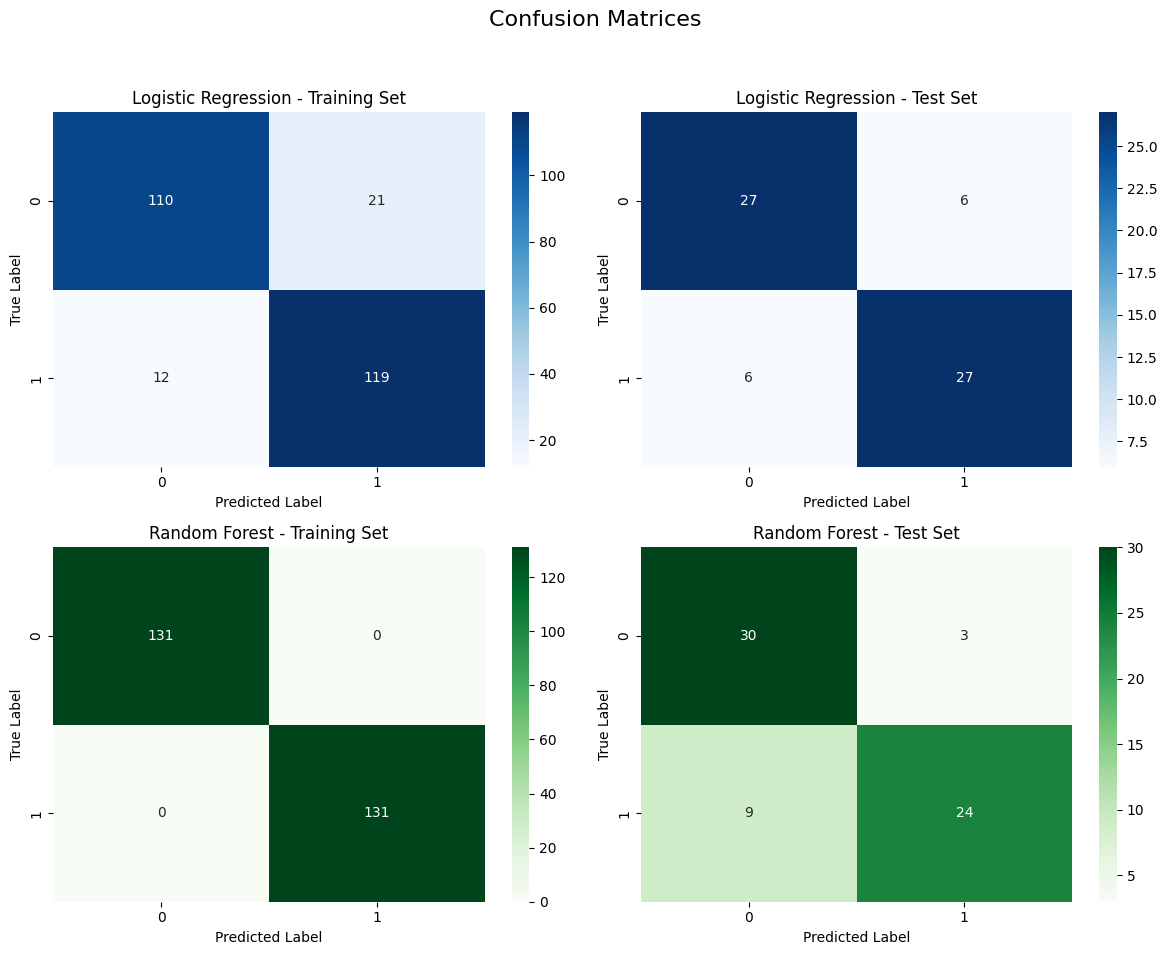

Confusion matrices for both models on training and test sets displayed.


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices', fontsize=16)

# Logistic Regression - Training Set
sns.heatmap(confusion_matrix(y_train, y_pred_log_reg_train), annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Logistic Regression - Training Set')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# Logistic Regression - Test Set
sns.heatmap(confusion_matrix(y_test, y_pred_log_reg_test), annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Logistic Regression - Test Set')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')

# Random Forest - Training Set
sns.heatmap(confusion_matrix(y_train, y_pred_rf_train), annot=True, fmt='d', cmap='Greens', ax=axes[1, 0])
axes[1, 0].set_title('Random Forest - Training Set')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# Random Forest - Test Set
sns.heatmap(confusion_matrix(y_test, y_pred_rf_test), annot=True, fmt='d', cmap='Greens', ax=axes[1, 1])
axes[1, 1].set_title('Random Forest - Test Set')
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Confusion matrices for both models on training and test sets displayed.")

**Reasoning**:
Next, as per instructions 7 and 8, predict probabilities for the positive class for both Logistic Regression and Random Forest models on both the training and test sets. These probabilities are necessary for generating ROC curves and calculating AUC scores.



In [24]:
y_prob_log_reg_train = log_reg_model.predict_proba(X_train)[:, 1]
y_prob_log_reg_test = log_reg_model.predict_proba(X_test)[:, 1]

y_prob_rf_train = rf_model.predict_proba(X_train)[:, 1]
y_prob_rf_test = rf_model.predict_proba(X_test)[:, 1]

print("Probabilities for positive class predicted for both Logistic Regression and Random Forest models on both training and test sets.")

Probabilities for positive class predicted for both Logistic Regression and Random Forest models on both training and test sets.


**Reasoning**:
Next, as per instructions 9 and 10, plot the ROC curve and calculate the AUC for both Logistic Regression and Random Forest models on both the training and test sets, ensuring proper titles, axis labels, and legends.



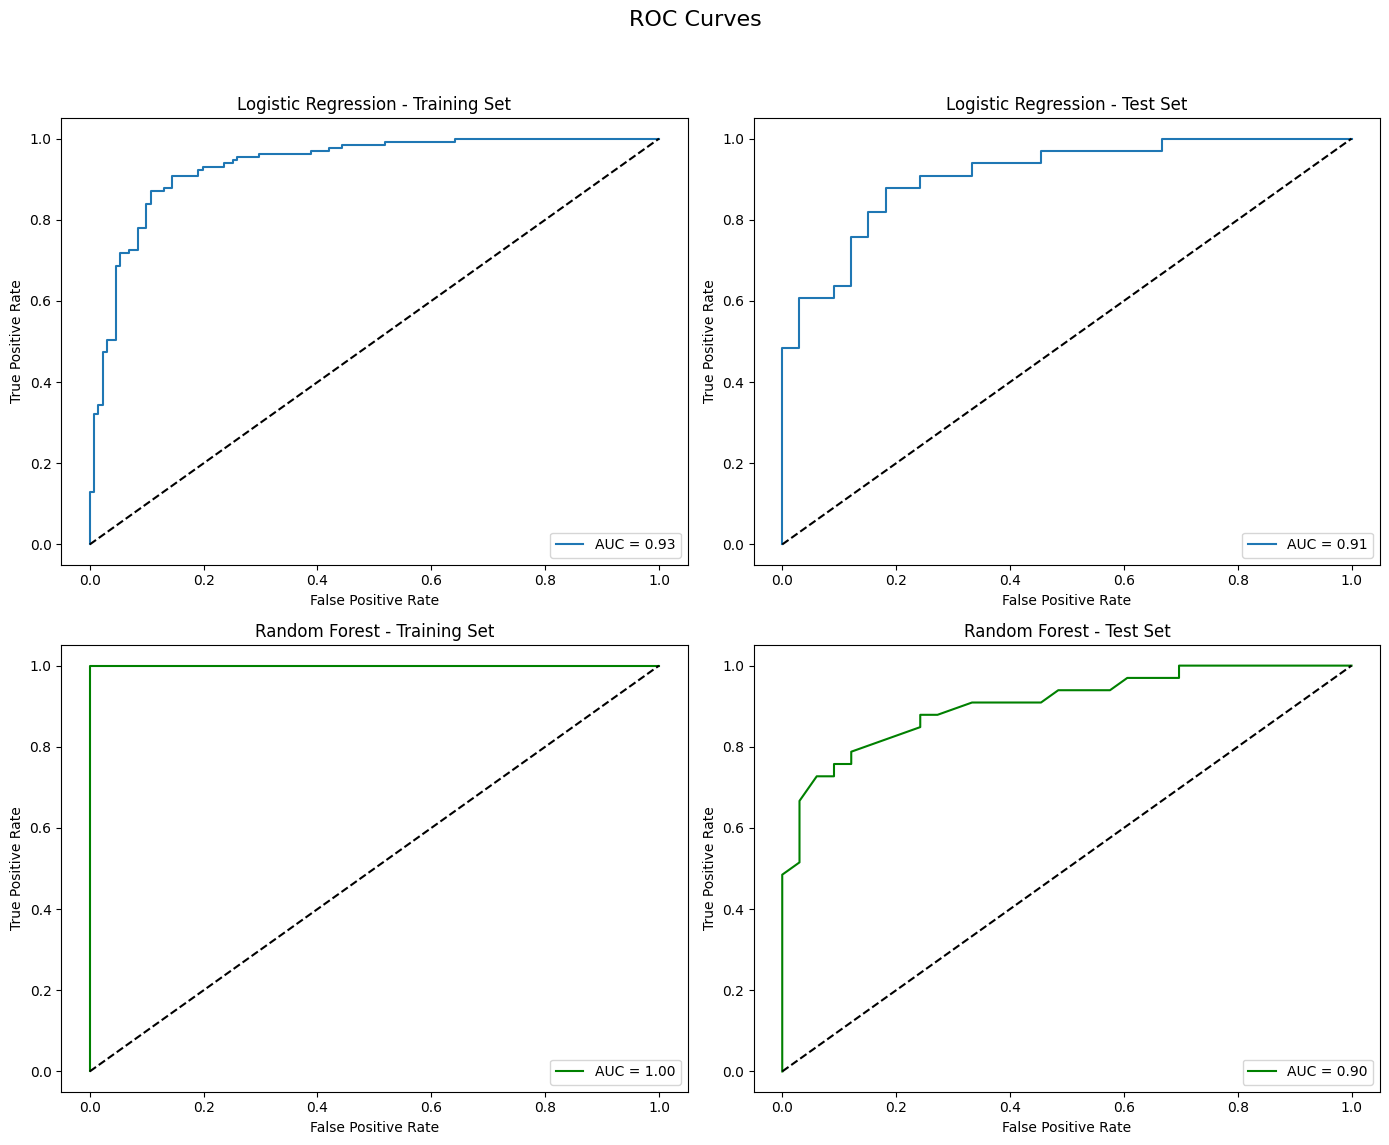

ROC curves and AUC scores for both models on training and test sets displayed.


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('ROC Curves', fontsize=16)

# Logistic Regression - Training Set
fpr_lr_train, tpr_lr_train, _ = roc_curve(y_train, y_prob_log_reg_train)
auc_lr_train = auc(fpr_lr_train, tpr_lr_train)
axes[0, 0].plot(fpr_lr_train, tpr_lr_train, label=f'AUC = {auc_lr_train:.2f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_title('Logistic Regression - Training Set')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].legend(loc='lower right')

# Logistic Regression - Test Set
fpr_lr_test, tpr_lr_test, _ = roc_curve(y_test, y_prob_log_reg_test)
auc_lr_test = auc(fpr_lr_test, tpr_lr_test)
axes[0, 1].plot(fpr_lr_test, tpr_lr_test, label=f'AUC = {auc_lr_test:.2f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--')
axes[0, 1].set_title('Logistic Regression - Test Set')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc='lower right')

# Random Forest - Training Set
fpr_rf_train, tpr_rf_train, _ = roc_curve(y_train, y_prob_rf_train)
auc_rf_train = auc(fpr_rf_train, tpr_rf_train)
axes[1, 0].plot(fpr_rf_train, tpr_rf_train, label=f'AUC = {auc_rf_train:.2f}', color='green')
axes[1, 0].plot([0, 1], [0, 1], 'k--')
axes[1, 0].set_title('Random Forest - Training Set')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend(loc='lower right')

# Random Forest - Test Set
fpr_rf_test, tpr_rf_test, _ = roc_curve(y_test, y_prob_rf_test)
auc_rf_test = auc(fpr_rf_test, tpr_rf_test)
axes[1, 1].plot(fpr_rf_test, tpr_rf_test, label=f'AUC = {auc_rf_test:.2f}', color='green')
axes[1, 1].plot([0, 1], [0, 1], 'k--')
axes[1, 1].set_title('Random Forest - Test Set')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend(loc='lower right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("ROC curves and AUC scores for both models on training and test sets displayed.")

### Model Performance Summary

**Logistic Regression Model:**
- **Training Set Performance:**
  - Accuracy: 0.8740
  - Recall: 0.9084
  - F1-Score: 0.8782
  - Precision: 0.8500
  - AUC: 0.93
  - The training set metrics indicate a good fit on the training data.
- **Test Set Performance:**
  - Accuracy: 0.8182
  - Recall: 0.8182
  - F1-Score: 0.8182
  - Precision: 0.8182
  - AUC: 0.91
  - There is a slight drop in performance from training to test set, which is expected. The model generalizes reasonably well to unseen data, maintaining a balanced performance across accuracy, recall, and precision.

**Random Forest Model:**
- **Training Set Performance:**
  - Accuracy: 1.0000
  - Recall: 1.0000
  - F1-Score: 1.0000
  - Precision: 1.0000
  - AUC: 1.00
  - The perfect scores on the training set clearly indicate **overfitting**. The model has learned the training data too well, including noise.
- **Test Set Performance:**
  - Accuracy: 0.8182
  - Recall: 0.7273
  - F1-Score: 0.8000
  - Precision: 0.8889
  - AUC: 0.90
  - While the test set accuracy is similar to Logistic Regression, the recall (0.7273) is lower, suggesting it misses more positive cases compared to Logistic Regression, though its precision is higher. The significant drop from 1.00 AUC on training to 0.90 AUC on test further confirms the overfitting observed in the training metrics.

**Comparison and Conclusion:**
- Both models show comparable performance on the test set in terms of overall accuracy and AUC, with Logistic Regression slightly outperforming Random Forest in recall on the test set. However, Random Forest exhibits clear signs of overfitting, as evidenced by its perfect training scores and subsequent drop in performance on the test set.
- **Logistic Regression** appears to be a more robust model for this dataset, providing a good balance between bias and variance, and generalizing better to unseen data compared to the un-tuned Random Forest model. Further hyperparameter tuning for Random Forest might mitigate the overfitting.

## Final Task

### Subtask:
Summarize the model training and evaluation process, including the performance of both Logistic Regression and Random Forest models for heart disease prediction.


## Summary:

### Q&A
The model training and evaluation process involved applying Logistic Regression and Random Forest models for heart disease prediction. The models were trained on a preprocessed and PCA-transformed dataset, and their performance was assessed using various metrics on both training and test sets.

For **Logistic Regression**, training performance showed an accuracy of 0.8740 and an AUC of 0.93. On the test set, it achieved an accuracy of 0.8182, recall of 0.8182, F1-score of 0.8182, precision of 0.8182, and an AUC of 0.91. This indicates a good balance between bias and variance, with reasonable generalization to unseen data.

For **Random Forest**, the training performance was perfect, with an accuracy, recall, F1-score, precision, and AUC all at 1.0000. However, its test set performance dropped significantly, achieving an accuracy of 0.8182, recall of 0.7273, F1-score of 0.8000, precision of 0.8889, and an AUC of 0.90. This significant discrepancy between training and test metrics clearly demonstrates overfitting.

### Data Analysis Key Findings

*   **Data Cleaning and Balancing:**
    *   The initial dataset contained 723 duplicate entries, which were removed, reducing the DataFrame size from 1025 to 302 rows.
    *   SMOTE was applied to address class imbalance, resulting in a balanced dataset where both target classes had 164 instances.
*   **Dimensionality Reduction with PCA:**
    *   After standardizing the features, Principal Component Analysis (PCA) was performed.
    *   12 principal components were selected, which collectively explained at least 95% of the total variance in the dataset, successfully reducing the dimensionality from 13 to 12 features.
*   **Model Performance - Logistic Regression:**
    *   The Logistic Regression model exhibited robust performance with an accuracy of 0.8182, recall of 0.8182, F1-score of 0.8182, and precision of 0.8182 on the test set.
    *   It achieved a strong AUC score of 0.91 on the test set, demonstrating good discriminatory power.
    *   The model showed good generalization with a small performance drop from training (AUC 0.93) to test (AUC 0.91).
*   **Model Performance - Random Forest:**
    *   The Random Forest model achieved perfect scores on the training set (accuracy, recall, F1-score, precision, and AUC all 1.0000), indicating severe overfitting.
    *   On the test set, its performance significantly dropped, yielding an accuracy of 0.8182, recall of 0.7273, F1-score of 0.8000, precision of 0.8889, and an AUC of 0.90.
    *   The recall for Random Forest on the test set (0.7273) was lower than that of Logistic Regression (0.8182), suggesting it missed more positive cases.

### Insights or Next Steps
*   **Favor Logistic Regression for Current Performance:** The Logistic Regression model demonstrates better generalization and less overfitting compared to the Random Forest model in its current state, making it a more reliable choice for predicting heart disease given the existing data and model configurations.
*   **Hyperparameter Tuning for Random Forest:** To mitigate overfitting and potentially improve the Random Forest model's test set performance, consider performing hyperparameter tuning (e.g., adjusting `max_depth`, `n_estimators`, `min_samples_leaf`) using techniques like GridSearchCV or RandomizedSearchCV.


PART 2: MODEL DEPL0YMENT

In [26]:
import joblib

# Define filenames for the models
log_reg_model_filename = 'logistic_regression_model.joblib'
rf_model_filename = 'random_forest_model.joblib'

# Save Logistic Regression model
joblib.dump(log_reg_model, log_reg_model_filename)
print(f'Logistic Regression model saved to {log_reg_model_filename}')

# Save Random Forest model
joblib.dump(rf_model, rf_model_filename)
print(f'Random Forest model saved to {rf_model_filename}')


Logistic Regression model saved to logistic_regression_model.joblib
Random Forest model saved to random_forest_model.joblib


### Explanation for Model Saving and Deployment

Here's how you can save your trained models and use them for deployment in a webpage:

**1. Saving the Models (as done above):**
The `joblib.dump()` function serializes the model objects (`log_reg_model` and `rf_model`) into binary files. These files contain all the information needed to recreate the models later.

**2. Loading the Models for Deployment:**
In your webpage's backend (e.g., using Flask, Django, or Node.js with a Python subprocess/API), you would load these saved models. For example, in Python:

```python
import joblib

# Load the Logistic Regression model
loaded_log_reg_model = joblib.load('logistic_regression_model.joblib')

# Load the Random Forest model
loaded_rf_model = joblib.load('random_forest_model.joblib')

# Now you can use loaded_log_reg_model.predict(new_data) or loaded_rf_model.predict(new_data)
```

**3. Integrating with a Webpage (e.g., using Flask/Python Backend):**
If you're creating a webpage with VS Code, you'll likely have a frontend (HTML, CSS, JavaScript) and a backend. A common approach is to use a Python-based web framework like Flask or Django for your backend.

Your backend would:
*   Load the saved models once when the server starts.
*   Expose an API endpoint (e.g., `/predict`) that receives new patient data from your frontend.
*   Preprocess the incoming data (scale, apply PCA using the *same scaler and PCA object* used during training - these should also be saved).
*   Use the loaded models to make predictions.
*   Return the prediction results to the frontend.

**Important Considerations:**
*   **Scaler and PCA:** Remember that your data was scaled using `StandardScaler` and transformed using `PCA`. You *must* save these objects too and use them to preprocess any new data before feeding it to your deployed models. You would save them similarly: `joblib.dump(scaler, 'scaler.joblib')` and `joblib.dump(pca, 'pca.joblib')`.
*   **Environment:** Ensure your deployment environment has all the necessary Python libraries (`scikit-learn`, `pandas`, `numpy`, `imbalanced-learn`, `joblib`) installed and that the paths to your saved model files are correct.